# Align the conditioned backbone with reward function

## Step 1: Find the residual vector field by solving a PDE using PINN

In [1]:
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

import model as _m; importlib.reload(_m)
import flow as _f; importlib.reload(_f)
import data as _d; importlib.reload(_d)

from model import ConditionalMLPVelocity, PINN, Reward2D
from flow import sample_trajectory
from data import SwissrollWithLabel, sample_noise

In [2]:
device = "cpu"
NUM_CLASSES = SwissrollWithLabel.NUM_CLASSES

# ---- Frozen base model (conditioned backbone) ----
v_base = ConditionalMLPVelocity(cond_dim=4, num_classes=NUM_CLASSES, dropout_prob=0.1)
v_base.load_state_dict(torch.load("conditioned_backbone.pt", map_location=device))
v_base.eval()
for p in v_base.parameters():
    p.requires_grad_(False)

# ---- Reward function (no trainable params) ----
reward_fn = Reward2D(num_classes=NUM_CLASSES)

# ---- PINN value network ----
pinn = PINN(cond_dim=4, num_classes=NUM_CLASSES)
lam = 1.0

print(f"PINN parameters: {sum(p.numel() for p in pinn.parameters()):,}")

PINN parameters: 83,615


In [3]:
eps = 1e-3
e1 = torch.tensor([[eps, 0.0]], device=device)
e2 = torch.tensor([[0.0, eps]], device=device)
dt_eps = torch.tensor([[eps]], device=device)
log_every = 500
history = {"loss": [], "pde": [], "bdy": [], "con": []}

# =====================================================================
# Phase 1 — Boundary warmup (w-head learns w(x,1,c) ≈ −∇r)
#   No PDE, no consistency: avoids competing gradients that pin w ≈ 0.
#   Higher lr lets Adam overcome the stochastic noise of the target.
# =====================================================================
warmup_epochs = 3000
warmup_bs = 1024
opt_warmup = torch.optim.Adam(pinn.parameters(), lr=1e-2)
sched_warmup = torch.optim.lr_scheduler.CosineAnnealingLR(opt_warmup, warmup_epochs, eta_min=1e-3)

pinn.train()
for epoch in range(1, warmup_epochs + 1):
    xb = torch.randn(warmup_bs, 2, device=device)
    cb = torch.randint(0, NUM_CLASSES, (warmup_bs,), device=device)
    tb = torch.ones(warmup_bs, 1, device=device)

    wb = pinn(xb, tb, cb)

    xb_g = xb.detach().requires_grad_(True)
    r = reward_fn(xb_g, cb)
    dr_dx = torch.autograd.grad(r.sum(), xb_g)[0].detach()

    loss_bdy = ((wb + dr_dx) ** 2).sum(dim=1).mean()

    opt_warmup.zero_grad()
    loss_bdy.backward()
    opt_warmup.step()
    sched_warmup.step()

    history["loss"].append(loss_bdy.item())
    history["pde"].append(0.0)
    history["bdy"].append(loss_bdy.item())
    history["con"].append(0.0)

    if epoch % log_every == 0:
        print(f"[Warmup {epoch}/{warmup_epochs}]  bdy={loss_bdy.item():.4e}  lr={opt_warmup.param_groups[0]['lr']:.2e}")

# =====================================================================
# Phase 2 — Full PINN training (PDE + boundary + consistency)
# =====================================================================
pde_epochs = 5000
batch_size = 512
alpha_bdy = 5.0
alpha_con = 0.5
opt_pde = torch.optim.Adam(pinn.parameters(), lr=1e-3)
sched_pde = torch.optim.lr_scheduler.CosineAnnealingLR(opt_pde, pde_epochs, eta_min=1e-5)

for epoch in range(1, pde_epochs + 1):
    x = torch.randn(batch_size, 2, device=device)
    t = torch.rand(batch_size, 1, device=device).clamp(eps, 1.0 - eps)
    c = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)

    V0, w0 = pinn.forward_all(x, t, c)

    Vtp = pinn.potential(x, t + dt_eps, c)
    Vtm = pinn.potential(x, t - dt_eps, c)
    dV_dt = (Vtp - Vtm) / (2 * eps)

    Vxp1 = pinn.potential(x + e1, t, c)
    Vxm1 = pinn.potential(x - e1, t, c)
    Vxp2 = pinn.potential(x + e2, t, c)
    Vxm2 = pinn.potential(x - e2, t, c)
    fd_grad = torch.cat([(Vxp1 - Vxm1), (Vxp2 - Vxm2)], dim=1) / (2 * eps)

    with torch.no_grad():
        v = v_base(x, t, c)

    grad_sq = (w0 ** 2).sum(dim=1, keepdim=True)
    dot_val = (w0 * v).sum(dim=1, keepdim=True)
    residual = dV_dt - grad_sq / (2 * lam) + dot_val
    loss_pde = (residual ** 2).mean()

    loss_con = ((w0 - fd_grad) ** 2).sum(dim=1).mean()

    xb = torch.randn(batch_size, 2, device=device)
    cb = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)
    tb = torch.ones(batch_size, 1, device=device)
    wb = pinn(xb, tb, cb)
    xb_g = xb.detach().requires_grad_(True)
    rb = reward_fn(xb_g, cb)
    dr_dx = torch.autograd.grad(rb.sum(), xb_g)[0].detach()
    loss_bdy = ((wb + dr_dx) ** 2).sum(dim=1).mean()

    loss = loss_pde + alpha_bdy * loss_bdy + alpha_con * loss_con

    opt_pde.zero_grad()
    loss.backward()
    opt_pde.step()
    sched_pde.step()

    history["loss"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["bdy"].append(loss_bdy.item())
    history["con"].append(loss_con.item())

    if epoch % log_every == 0:
        print(
            f"[PDE {epoch}/{pde_epochs}]  loss={loss.item():.4e}  "
            f"pde={loss_pde.item():.4e}  bdy={loss_bdy.item():.4e}  "
            f"con={loss_con.item():.4e}"
        )

# ---- Diagnostic ----
pinn.eval()
with torch.no_grad():
    x_test = torch.randn(512, 2, device=device)
    t_test = torch.ones(512, 1, device=device)
    c_test = torch.randint(0, NUM_CLASSES, (512,), device=device)
    w_test = pinn(x_test, t_test, c_test)
    v_b = v_base(x_test, t_test, c_test)
    ratio = w_test.norm(dim=1).mean() / v_b.norm(dim=1).mean()
    print(f"\n||w|| at t=1:   mean={w_test.norm(dim=1).mean():.4f}, max={w_test.norm(dim=1).max():.4f}")
    print(f"||v_base||:     mean={v_b.norm(dim=1).mean():.4f}")
    print(f"Correction ratio: {ratio:.4f}")

[Warmup 500/3000]  bdy=1.2531e-01  lr=9.40e-03
[Warmup 1000/3000]  bdy=4.9222e-02  lr=7.75e-03
[Warmup 1500/3000]  bdy=3.4448e-02  lr=5.50e-03
[Warmup 2000/3000]  bdy=1.8304e-02  lr=3.25e-03
[Warmup 2500/3000]  bdy=1.0826e-02  lr=1.60e-03
[Warmup 3000/3000]  bdy=6.3605e-03  lr=1.00e-03
[PDE 500/5000]  loss=2.2272e+01  pde=8.7388e+00  bdy=2.5342e+00  con=1.7253e+00
[PDE 1000/5000]  loss=1.1956e+01  pde=4.9062e+00  bdy=1.2778e+00  con=1.3210e+00
[PDE 1500/5000]  loss=7.7272e+00  pde=3.3848e+00  bdy=7.8961e-01  con=7.8880e-01
[PDE 2000/5000]  loss=6.2768e+00  pde=3.3863e+00  bdy=4.8333e-01  con=9.4771e-01
[PDE 2500/5000]  loss=3.2785e+00  pde=1.2314e+00  bdy=3.4490e-01  con=6.4520e-01
[PDE 3000/5000]  loss=3.5052e+00  pde=1.7973e+00  bdy=2.6021e-01  con=8.1382e-01
[PDE 3500/5000]  loss=2.3363e+00  pde=8.5980e-01  bdy=2.2673e-01  con=6.8571e-01
[PDE 4000/5000]  loss=2.0680e+00  pde=8.8053e-01  bdy=1.6870e-01  con=6.8792e-01
[PDE 4500/5000]  loss=2.2704e+00  pde=8.8526e-01  bdy=2.1097e-01  

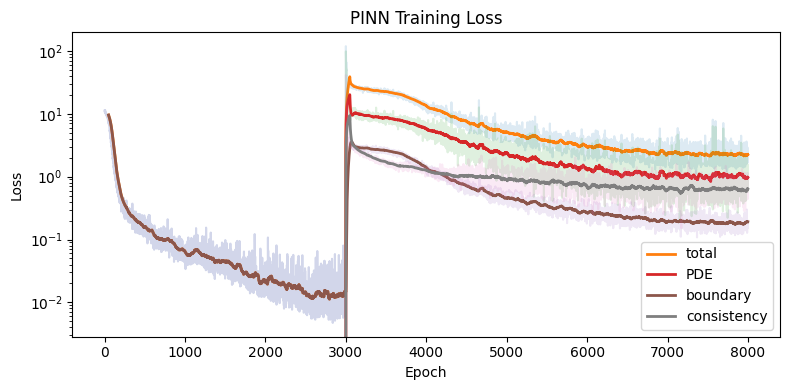

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 50
for key, label in [("loss", "total"), ("pde", "PDE"), ("bdy", "boundary"), ("con", "consistency")]:
    raw = history[key]
    ax.plot(raw, alpha=0.15)
    smoothed = np.convolve(raw, np.ones(w) / w, mode="valid")
    ax.plot(range(w - 1, len(raw)), smoothed, linewidth=2, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.set_title("PINN Training Loss")
plt.tight_layout()
plt.show()

## Step 2: Aligned sampling — $v_{\text{aligned}} = v_{\text{base}} + \nabla_x V_\phi$

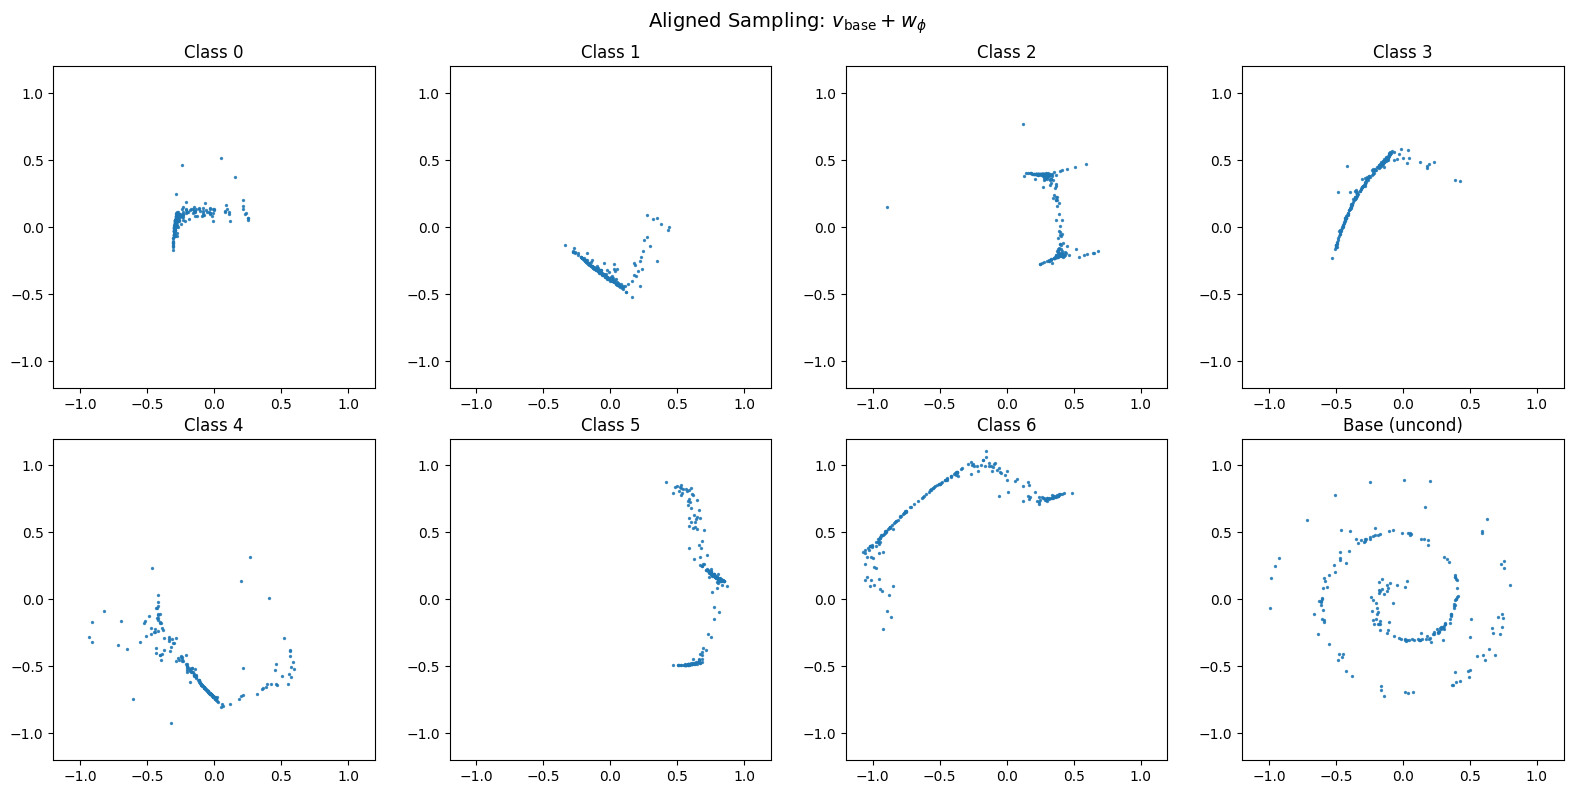

In [5]:
pinn.eval()
n_per_class = 200

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for label in range(NUM_CLASSES + 1):
    ax = axes[label // 4, label % 4]
    x0 = sample_noise(n_per_class, device=device, seed=label)

    if label < NUM_CLASSES:
        label_t = torch.full((n_per_class,), label, dtype=torch.long, device=device)
        traj = sample_trajectory(
            x0,
            lambda x, t, c=label_t: v_base(x, t, c) + pinn(x, t, c),
            n_steps=80,
        )
        title = f"Class {label}"
    else:
        uncond = torch.full((n_per_class,), NUM_CLASSES, dtype=torch.long, device=device)
        traj = sample_trajectory(
            x0,
            lambda x, t, c=uncond: v_base(x, t, c),
            n_steps=80,
        )
        title = "Base (uncond)"

    x1 = traj["xs"][-1].cpu().numpy()
    ax.scatter(x1[:, 0], x1[:, 1], marker=".", s=8, alpha=0.8)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

plt.suptitle(r"Aligned Sampling: $v_{\mathrm{base}} + w_\phi$", fontsize=14)
plt.tight_layout()
plt.show()